In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [45]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [46]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDescriptive Statistics")
print(df.describe())

Shape of Dataset: (1460, 81)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Ov

Available columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', '

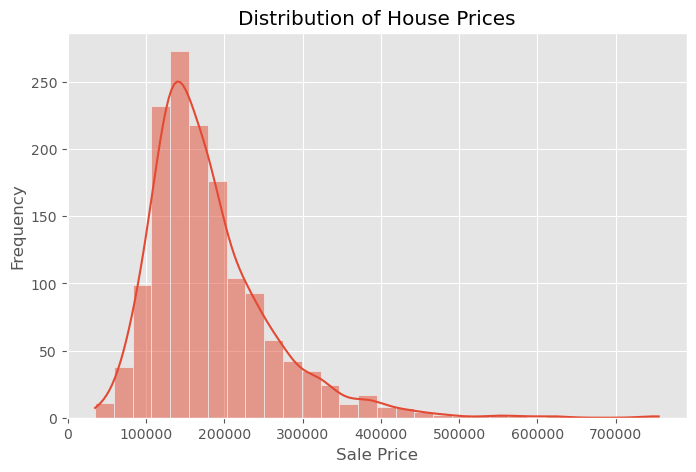

In [47]:

print("Available columns:", df.columns.tolist())


print("\nDataFrame info:")
print(df.head())
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=30, kde=True)  

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()



In [48]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [49]:
drop_columns = ["PoolQC","Fence","MiscFeature","Alley"]

df.drop(columns=drop_columns, inplace=True)

In [50]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [51]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [52]:
print(df.isnull().sum().sum())

0


In [53]:
df = pd.get_dummies(df, drop_first=True)

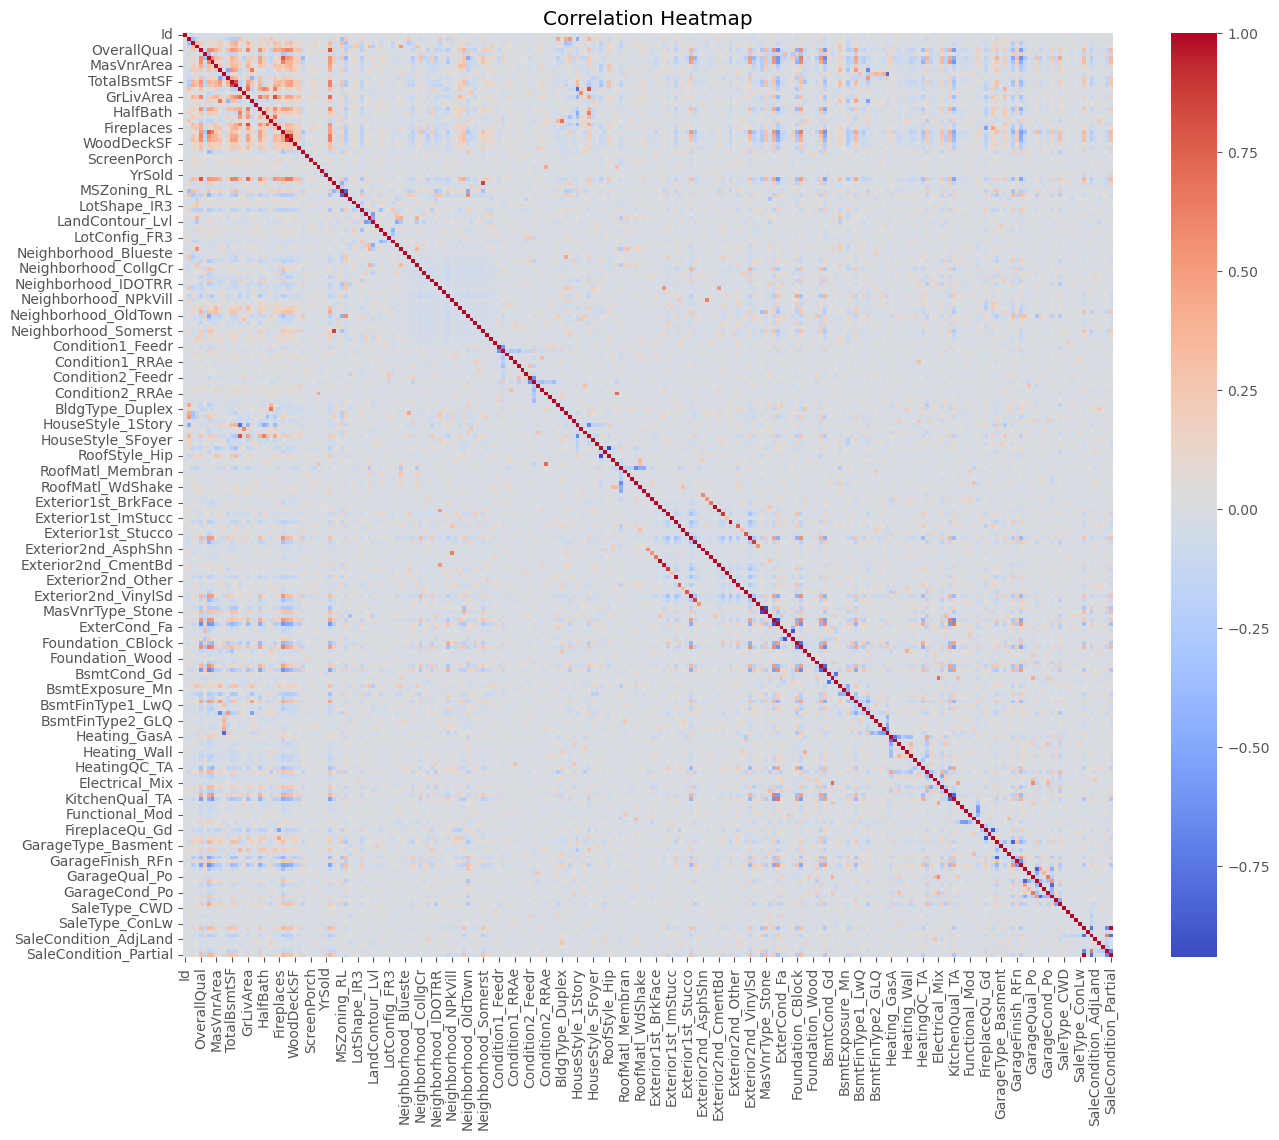

In [54]:
plt.figure(figsize=(15,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [55]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42
)

In [57]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [58]:
predictions = model.predict(X_test)

predictions[:10]

array([155938.41042558, 352300.00992554,  89640.30702609, 174631.19070086,
       321755.05175991,  66177.61488861, 233101.78149836, 147426.86211238,
        57348.01570895, 147534.70815784])

In [59]:
mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Squared Error: 2736914087.721727
Root Mean Squared Error: 52315.52434719284
R2 Score: 0.6431815266008859


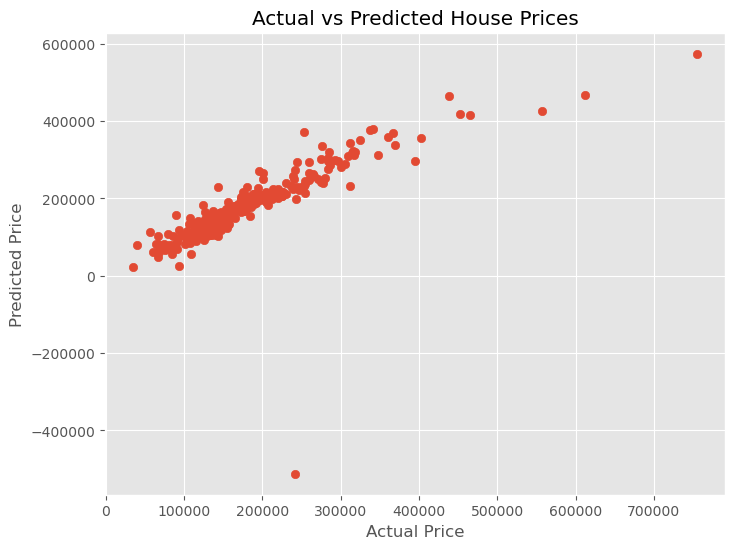

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

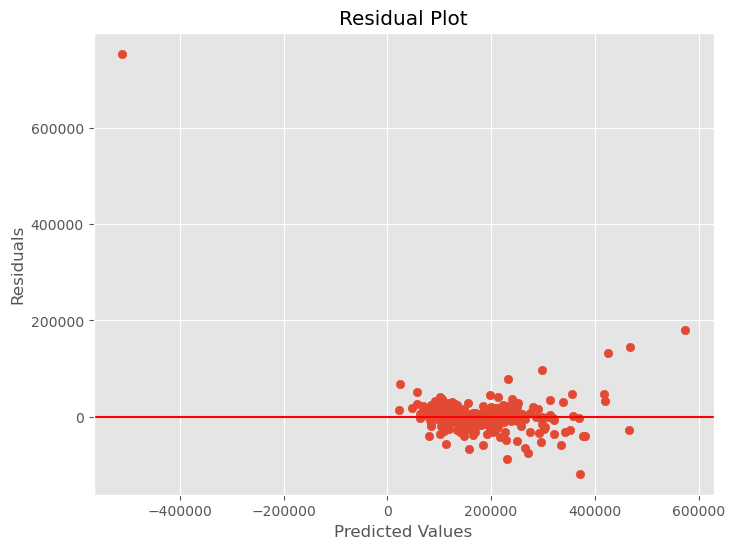

In [61]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [62]:
importance = pd.DataFrame({

"Feature": X.columns,

"Coefficient": model.coef_

})

importance = importance.sort_values(

by="Coefficient",

ascending=False
)

importance.head(10)

,Feature,Coefficient
112,RoofMatl_Metal,721425.389002
116,RoofMatl_WdShngl,685501.552106
114,RoofMatl_Tar&Grv,677334.625808
115,RoofMatl_WdShake,676362.148113
110,RoofMatl_CompShg,675084.644700
113,RoofMatl_Roll,674773.596769
220,GarageCond_TA,148791.161631
217,GarageCond_Fa,146320.776658
218,GarageCond_Gd,144967.810777
219,GarageCond_Po,142238.096018


In [ ]:
Conclusion

1. The dataset was successfully loaded and cleaned.

2. Missing values were handled using median and mode.

3. Categorical variables were converted using One-Hot Encoding.

4. A Linear Regression model was trained.

5. The model was evaluated using MSE, RMSE and R² Score.

6. Actual vs Predicted and Residual plots indicate satisfactory model performance.

7. The most influential features affecting house prices were identified.

In [ ]:
1. Focus on improving the features that have the strongest positive coefficients, such as overall quality and living area, to increase property value.

2. Maintain complete and accurate property records because missing data reduces model reliability.

3. Use predictive models to estimate house prices before listing properties, helping buyers and sellers make informed decisions.